## HateXplain - 2 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman

### Methods

* **MOLA**
* **Random Weights**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from transformers import AutoModel
from collections import Counter
from tqdm import tqdm
from datasets import load_dataset


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from ml_moo import moo, get_objectives, MooScalarization
from ml_moo.analysis.metrics import compute_hypervolume_progress
from ml_moo.analysis.visualization import plot_pareto_2d, plot_multiple_hypervolumes, plot_hypervolume
from ml_moo.scalarization.two_objs_hate_speech import HateSpeechScalarization

In [4]:
# Definir seed para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)


In [6]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [7]:
print("GPU disponível:", torch.cuda.is_available())

GPU disponível: True


In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [9]:
device

device(type='cuda', index=0)

In [10]:
class MultiTaskHateSpeechDataset(Dataset):
    def __init__(self, dataset, tokenizer_name="bert-base-uncased", max_length=128):
        self.dataset = dataset
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length
        #self.bert_model = AutoModel.from_pretrained(tokenizer_name)
        #self.bert_model.eval()

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data = self.dataset[idx]

        # Converter lista de tokens em texto
        text = " ".join(data["post_tokens"])

        # Encontrar a moda dos rótulos (classificação de discurso de ódio)
        labels = data["annotators"]["label"]
        label_counts = Counter(labels)
        majority_label = label_counts.most_common(1)[0][0]  # Pega a moda
      
        label_hate = 0 if majority_label == 1 else 1

        # Criar rótulo para discurso de ódio contra gênero (exemplo: "women")
        target_groups = data["annotators"]["target"]

        hate_women = 0

        for i in range(len(target_groups)):
            if label_hate == 1:
                if ('Women' in target_groups[i]):
                    hate_women = 1

        # Tokenizar texto
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(label_hate, dtype=torch.long),
            "women_hate": torch.tensor(hate_women, dtype=torch.long)
        }

In [11]:
# Criar os datasets para treino, validação e teste
#train_dataset = MultiTaskHateSpeechDataset(dataset["train"])
#val_dataset = MultiTaskHateSpeechDataset(dataset["train"])
#test_dataset = MultiTaskHateSpeechDataset(dataset["train"])
#
## DataLoaders
#batch_size = 8
#trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#validloader = DataLoader(val_dataset, batch_size=batch_size)
#testloader = DataLoader(test_dataset, batch_size=batch_size)

In [12]:
def extract_bert_embeddings(dataset, tokenizer_name="bert-base-uncased", max_length=128, batch_size=32, device="cuda"):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model = AutoModel.from_pretrained(tokenizer_name).to(device)
    model.eval()

    texts = [" ".join(d["post_tokens"]) for d in dataset]

    embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[i:i+batch_size]
            encoding = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(device)

            outputs = model(**encoding)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # CLS token
            embeddings.append(cls_embeddings.cpu())

    return torch.cat(embeddings, dim=0)  # Shape: (N, hidden_size)

from sklearn.decomposition import PCA

def apply_pca_and_save(embeddings: torch.Tensor, n_components=50, output_path="embeddings_pca.npy"):
    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(embeddings.numpy())
    np.save(output_path, reduced)
    return reduced

from collections import Counter
from torch.utils.data import Dataset

class PCAEmbeddingsDataset(Dataset):
    def __init__(self, pca_embeddings: np.ndarray, raw_dataset):
        self.embeddings = torch.tensor(pca_embeddings, dtype=torch.float)
        self.raw_dataset = raw_dataset
        

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        data = self.raw_dataset[idx]

        labels = data["annotators"]["label"]
        majority_label = Counter(labels).most_common(1)[0][0]
        label_hate = 0 if majority_label == 1 else 1

        # Criar rótulo para discurso de ódio contra gênero (exemplo: "women")
        target_groups = data["annotators"]["target"]
        hate_women = 0
        hate_homosexual = 0
       
        for i in range(len(target_groups)):
            if label_hate == 1:
                if ('Women' in target_groups[i]):
                    hate_women = 1
                #if ('Homosexual' in target_groups[i]):
                #    hate_homosexual = 1

        return {
            "embedding": self.embeddings[idx],
            "label": torch.tensor(label_hate, dtype=torch.long),
            "women_hate": torch.tensor(hate_women, dtype=torch.long),
            #"homosexual_hate": torch.tensor(hate_homosexual, dtype=torch.long),
        }

# Suponha que você tenha carregado seu dataset JSON como `raw_dataset`

embeddings = extract_bert_embeddings(dataset["train"])
pca_embeddings = apply_pca_and_save(embeddings, n_components=50, output_path="embeddings_pca.npy")
#
## Agora use para treinar seu modelo
dataset_pca = PCAEmbeddingsDataset(pca_embeddings, dataset["train"])
train_dataloader = DataLoader(dataset_pca, batch_size=64, shuffle=True)


100%|██████████| 481/481 [00:47<00:00, 10.13it/s]


In [13]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 300,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}

93 min 28s - 50 iter

## MOLA

22:19:22 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
22:19:22 | DEBUG | ml_moo | Finding 1th individual minimum


device: cuda:0


Epoch 1/3 - Training: 100%|██████████| 241/241 [00:02<00:00, 119.81it/s]


Epoch 1 - Average training loss: 0.3672


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 128.14it/s]


...

Epoch 2 - Average training loss: 0.2066


Epoch 3/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 130.76it/s]


Epoch 3 - Average training loss: 0.2066


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 145.50it/s]
22:55:16 | DEBUG | ml_moo | Calculated weights: [0.20379004 0.79620996]
22:55:16 | DEBUG | ml_moo | Importance: 7.102814873094498e-05
22:55:16 | DEBUG | ml_moo | Global lower bound (y*): [0.58876114 0.34952017]
22:55:16 | DEBUG | ml_moo | Iteration 301
22:55:16 | DEBUG | ml_moo | Solutions list: [array([0.58880806, 0.35010154]), array([0.58878434, 0.35040876]), array([0.58876114, 0.35057131]), array([0.58889136, 0.34973934]), array([0.58900972, 0.34960619]), array([0.58934583, 0.34952017]), array([0.58896134, 0.34965628]), array([0.58887355, 0.3499954 ])]


new solution dominated [0.5889152  0.35077806]


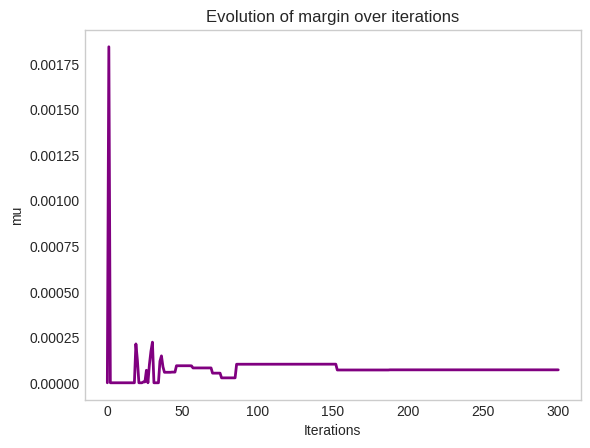

22:55:16 | INFO | ml_moo | Fit runtime: 2154.07 seconds


In [14]:
method = 'mola'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

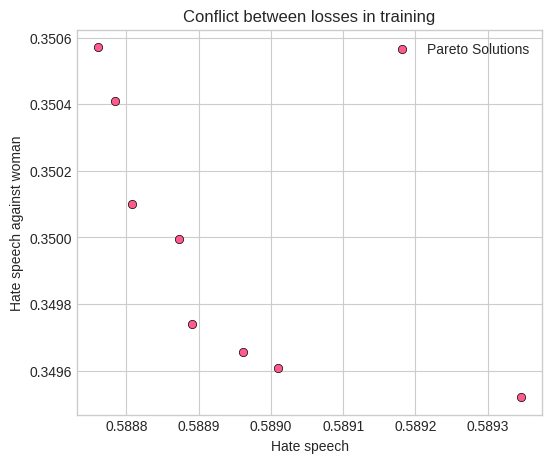

In [15]:
title="Conflict between losses in training"
plot_pareto_2d(objectives=objs, 
               labels=("Hate speech", "Hate speech against woman"), 
               title=title,
               #point = equal.objs,
               color="#FF5C8D"
               )

22:55:16 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
22:55:16 | DEBUG | ml_moo | Finding 1th individual minimum


device: cuda:0


Epoch 1/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 130.95it/s]


Epoch 1 - Average training loss: 0.3548


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 132.85it/s]


...

Epoch 2 - Average training loss: 0.2392


Epoch 3/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 134.84it/s]


Epoch 3 - Average training loss: 0.2387


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 155.83it/s]
23:31:08 | DEBUG | ml_moo | Calculated weights: [0.45984558 0.54015442]
23:31:08 | DEBUG | ml_moo | Importance: 0.0001075000070707155
23:31:08 | DEBUG | ml_moo | Global lower bound (y*): [0.58870736 0.34959805]
23:31:08 | DEBUG | ml_moo | Iteration 301
23:31:08 | DEBUG | ml_moo | Solutions list: [array([0.58965566, 0.34959805]), array([0.58935656, 0.34968   ]), array([0.58947152, 0.3496276 ]), array([0.58883798, 0.34990197]), array([0.58872004, 0.34999783]), array([0.58870736, 0.35074633]), array([0.58905867, 0.34970954])]


new solution dominated [0.58944802 0.35007568]


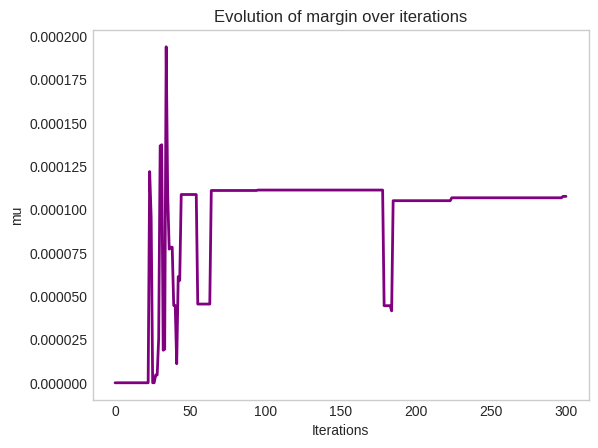

23:31:08 | INFO | ml_moo | Fit runtime: 2151.81 seconds


In [16]:
method = 'mola'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name, gradient=True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs_grad = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs_grad,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

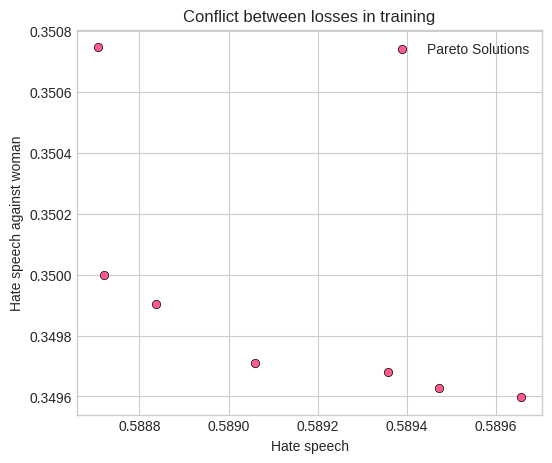

In [17]:
title="Conflict between losses in training"
plot_pareto_2d(objectives=objs_grad, 
               labels=("Hate speech", "Hate speech against woman"), 
               title=title,
               #point = equal.objs,
               color="#FF5C8D"
               )

## Hypervolume

In [18]:
#hv = compute_hypervolume_progress(solutions=moopt, method='mola')

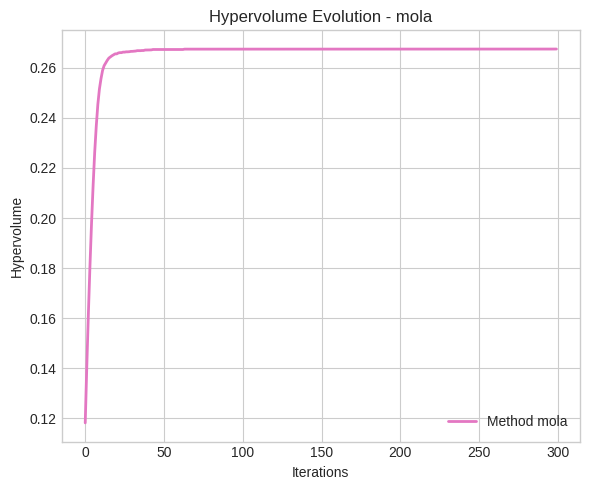

In [19]:
ml_hv = moopt.get_hypervolumes()
plot_hypervolume(ml_hv, 'mola')

### Ensemble

In [20]:
#moopt_models = moopt.get_models()

In [21]:
# from torch.nn.functional import softmax
# 
# def predict_probs(model, tokenizer, texts):
#     inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
#     with torch.no_grad():
#         logits = model(**inputs).logits
#         probs = softmax(logits, dim=1).numpy()
#     return probs
# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# # Para cada modelo
# for model in moopt_models:
#     probs += predict_probs(model, tokenizer, train_dataset['input_ids'])
# 
# # probs2 = predict_probs(model2, tokenizer, texts)
# # probs3 = predict_probs(model3, tokenizer, texts)
# # probs1 = predict_probs(model1, tokenizer, texts)
# 
# # Ensemble por média das probabilidades
# #avg_probs = (probs1 + probs2 + probs3) / 3
# avg_probs = probs / (len(moopt_models))
# final_preds = avg_probs.argmax(axis=1)

## Random Weight

+ 154

In [22]:
method = 'random_weight'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

23:31:08 | WARNING | ml_moo | Ignored parameters for random_weights: {'nodeGap', 'targetGap', 'nodeTimeLimit'}
23:31:08 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 300, 'norm': False}
23:31:08 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima


device: cuda:0


Epoch 1/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 125.35it/s]


Epoch 1 - Average training loss: 0.3457


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 132.01it/s]


...

Epoch 2/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 128.67it/s]


Epoch 2 - Average training loss: 0.2091


Epoch 3/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 130.07it/s]


Epoch 3 - Average training loss: 0.2075


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 146.53it/s]
00:06:49 | DEBUG | ml_moo.moo.random_weights | 300th solution


In [23]:
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support,f1_score

In [24]:
class MultiTaskModel(nn.Module):
    def __init__(self, model_name="tum-nlp/bert-hateXplain", num_labels=2, dropout_rate=0.3):
        super(MultiTaskModel, self).__init__()
        
        # Camada compartilhada: BERT
        self.shared_bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.shared_bert.config.hidden_size
        # print("hidden size", hidden_size)
        
        # Camadas adicionais compartilhadas
        self.dropout = nn.Dropout(dropout_rate)
        self.shared_fc = nn.Linear(hidden_size, 128)

        self.classifier_hate = nn.Linear(128, num_labels)  
        self.classifier_women = nn.Linear(128, num_labels)


    def forward(self, input_ids, attention_mask):
        # Passagem pela parte compartilhada
        outputs = self.shared_bert(input_ids=input_ids, attention_mask=attention_mask)

        pooled_output = outputs.last_hidden_state[:, 0, :]  # Token [CLS]
        pooled_output = self.dropout(pooled_output)
        
        hate_features = self.shared_fc(pooled_output)
        women_features = self.shared_fc(pooled_output)
        
        # Classificação final
        logits_hate = self.classifier_hate(hate_features)
        logits_women = self.classifier_women(women_features)

        return logits_hate, logits_women
    
def train_model(model, train_loader, val_loader, epochs=3):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = MultiTaskModel().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()

    best_val_f1 = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_hate = batch["label"].to(device)
            labels_women = batch["women_hate"].to(device)

            optimizer.zero_grad()
                
            logits_hate, logits_women = model(input_ids, attention_mask)

            # Calcular perdas
            loss_hate = criterion(logits_hate, labels_hate)
            loss_women = criterion(logits_women, labels_women)
            
            # Balancear as perdas
            loss = (loss_hate + loss_women ) / 2
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
        avg_train_loss = train_loss / len(train_loader)
        print(f"Epoch {epoch+1} - Average training loss: {avg_train_loss:.4f}")

        # Validação
        val_metrics = evaluate_model(model, val_loader, device)
        print(f"Validation metrics - Hate F1: {val_metrics['hate_f1']:.4f}, women F1: {val_metrics['women_f1']:.4f}")
        print(f"Validation metrics - Hate ACC: {val_metrics['hate_acc']:.4f}, women ACC: {val_metrics['women_acc']:.4f}")
        

    return model

# Função de avaliação
def evaluate_model(model, dataloader, device):
    model.eval()
    
    all_preds_hate = []
    all_true_hate = []

    all_preds_women = []
    all_true_women = []

    total_loss_hate = 0.0
    total_loss_women = 0.0
    total_batches = 0

    
    # Definir os critérios de loss (provavelmente CrossEntropyLoss para classificação)
    loss_fn = torch.nn.CrossEntropyLoss()
 
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_hate = batch["label"].to(device)
            labels_women = batch["women_hate"].to(device)
            
            logits_hate, logits_women = model(input_ids, attention_mask)
            
            # Calcular loss para cada task
            loss_hate = loss_fn(logits_hate, labels_hate)
            loss_women = loss_fn(logits_women, labels_women)

            # Acumular losses
            total_loss_hate += loss_hate.item()
            total_loss_women += loss_women.item()
            total_batches += 1
            
            preds_hate = torch.argmax(logits_hate, dim=1).cpu().numpy()
            preds_women = torch.argmax(logits_women, dim=1).cpu().numpy()

            
            all_preds_hate.extend(preds_hate)
            all_true_hate.extend(labels_hate.cpu().numpy())

            all_preds_women.extend(preds_women)
            all_true_women.extend(labels_women.cpu().numpy())

     # Calcular médias das losses
    avg_loss_hate = total_loss_hate / total_batches
    avg_loss_women = total_loss_women / total_batches

    
    # Métricas
    hate_acc = accuracy_score(all_true_hate, all_preds_hate)
    hate_f1 = f1_score(all_true_hate, all_preds_hate)

    women_acc = accuracy_score(all_true_women, all_preds_women)
    women_f1 = f1_score(all_true_women, all_preds_women)

    return {
        "hate_acc": hate_acc,
        "hate_f1": hate_f1,
        "hate_loss": avg_loss_hate,
        "women_acc": women_acc,
        "women_f1": women_f1,
        "women_loss": avg_loss_women,
    }

# Instanciar e treinar o modelo
#model = MultiTaskModel(model_name)
#model = train_model(model, train_dataloader, val_loader=validloader, epochs=3)
#
## Avaliar no conjunto de teste
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#test_metrics = evaluate_model(model, testloader, device)
#
#print("\nTest Results:")
#print(f"Hate Speech Detection - Accuracy: {test_metrics['hate_acc']:.4f}, F1: {test_metrics['hate_f1']:.4f}, Loss: {test_metrics['hate_loss']:.4f}")
#print(f"women Classification - Accuracy: {test_metrics['women_acc']:.4f}, F1: {test_metrics['women_f1']:.4f}, Loss: {test_metrics['women_loss']:.4f}")


In [25]:
equal_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name)
equal_scalar.optimize(np.array([0.5, 0.5]))

device: cuda:0


Epoch 1/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 133.24it/s]


Epoch 1 - Average training loss: 0.3755


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 130.75it/s]


Epoch 2 - Average training loss: 0.3672


Epoch 3/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 131.42it/s]


Epoch 3 - Average training loss: 0.3602


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 151.48it/s]


In [26]:
equal_scalar.objs

array([0.71421265, 0.70431286])

In [27]:
ss = [np.array([0.94393057, 0.33407429]), np.array([1.09308704, 0.28218292]), np.array([0.89510419, 0.42376252]), np.array([0.89079394, 0.48900745]), np.array([0.88668042, 0.54351755])]

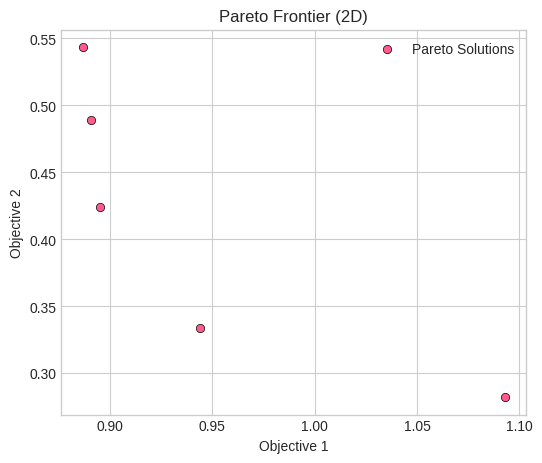

In [28]:
plot_pareto_2d(ss)

## Comparison between MOO methods

In [29]:
from ml_moo.tests.experiments.run import run_experiments
from ml_moo.analysis.moo_analyzer import Analyzer

00:06:56 | WARNING | ml_moo | [Methods have different numbers of solutions: {8, 300, 7}


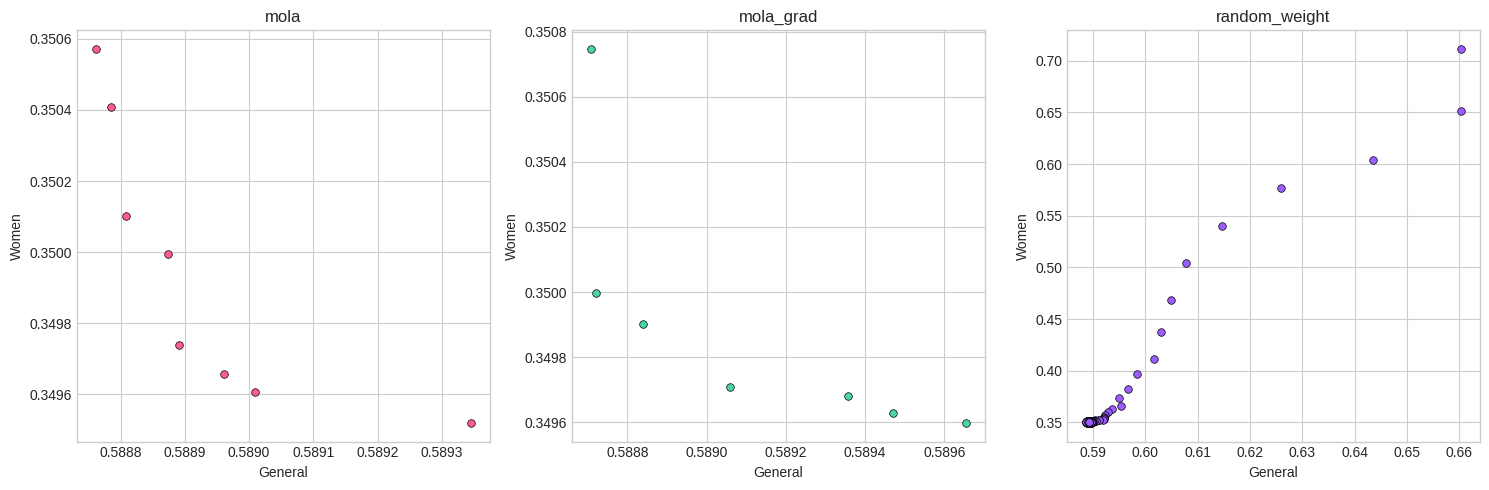

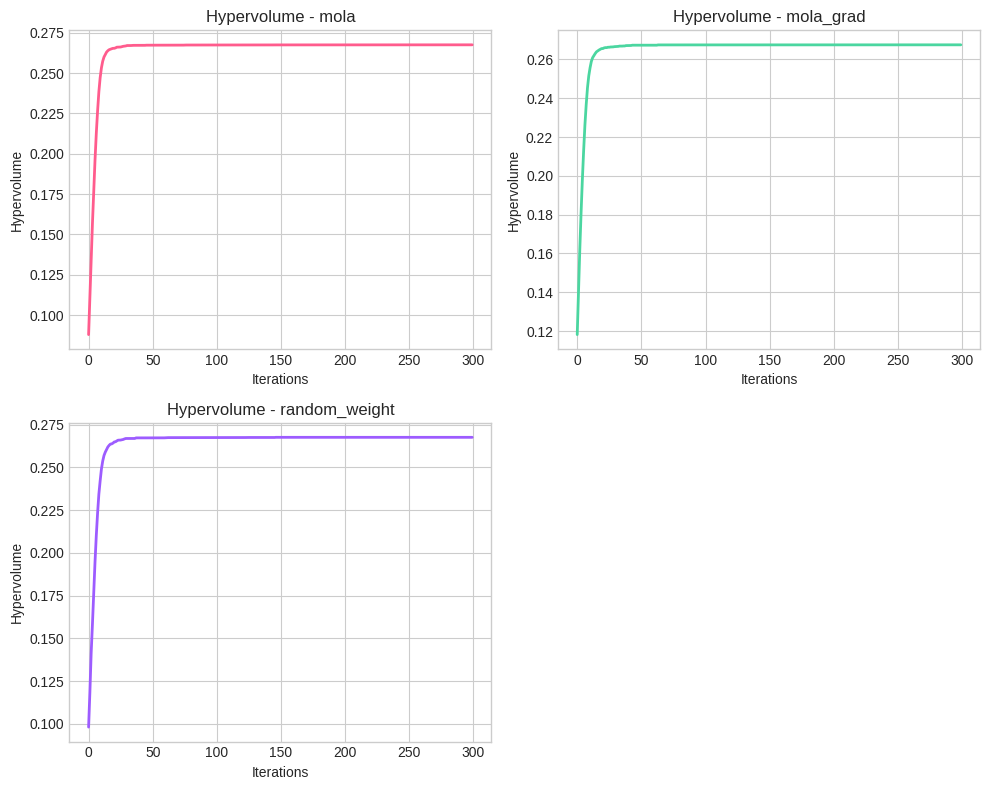

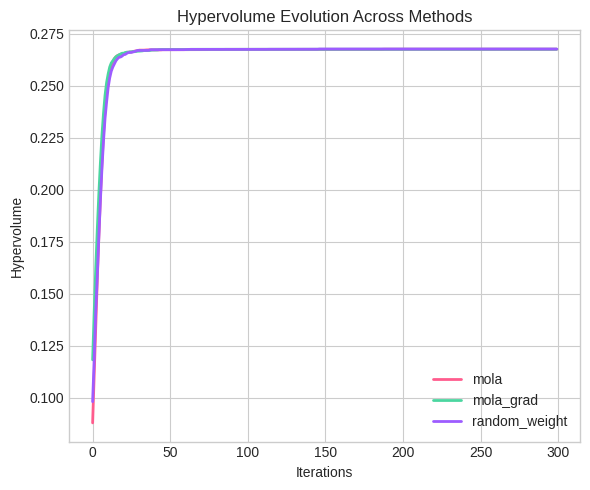

[Analyzer] Visualization complete.


In [30]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = ["General", "Women"]
Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      #point = equal_scalar.objs,
                      axis_label=axis_label
                      )

00:06:57 | WARNING | ml_moo | [Methods have different numbers of solutions: {8, 300, 7}


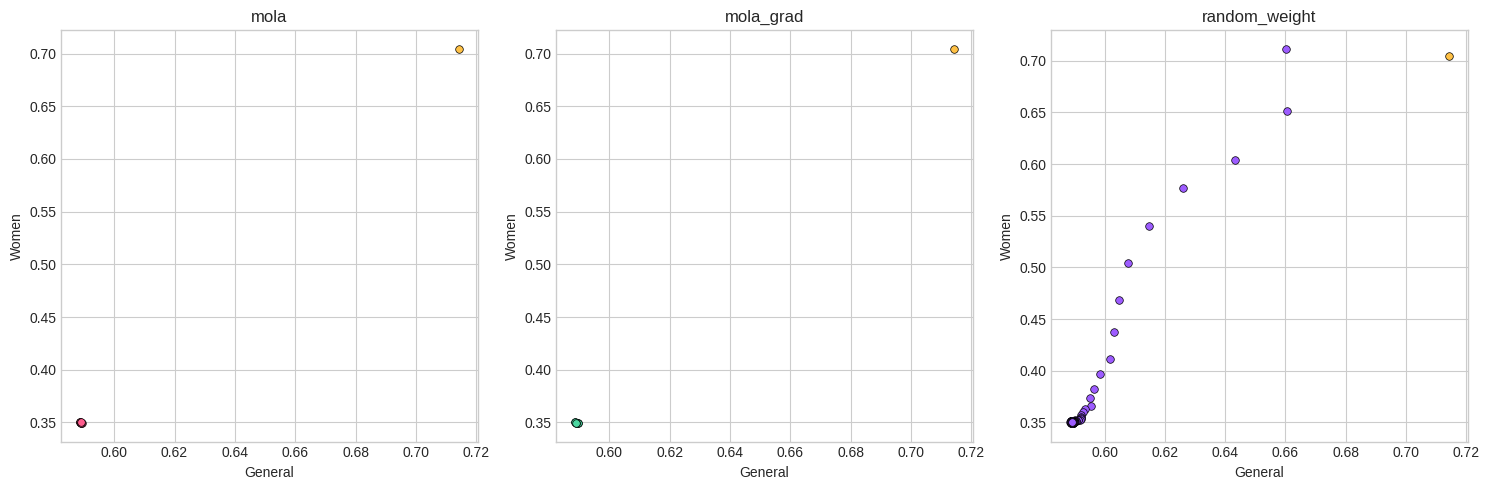

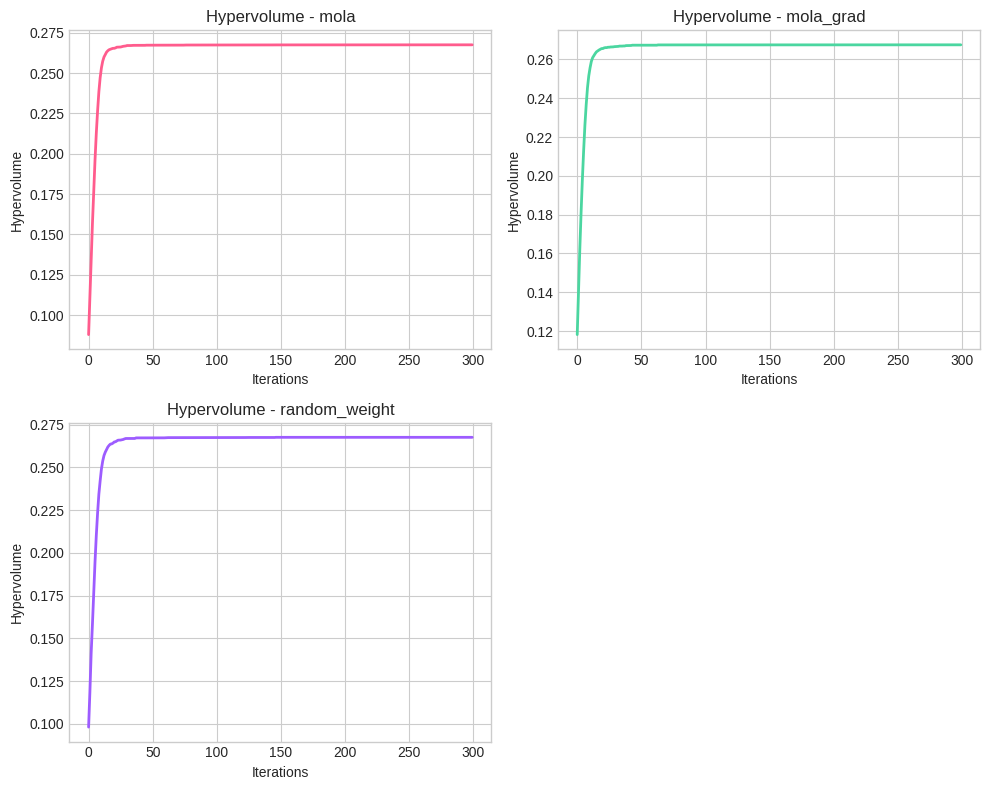

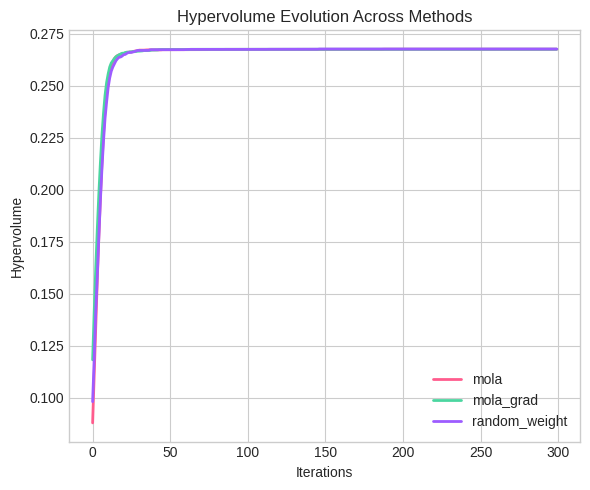

[Analyzer] Visualization complete.


In [31]:
colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = ["General", "Women"]
Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      point = equal_scalar.objs,
                      axis_label=axis_label
                      )

In [32]:
from ml_moo.analysis.visualization import plot_pareto_2d_set_limit

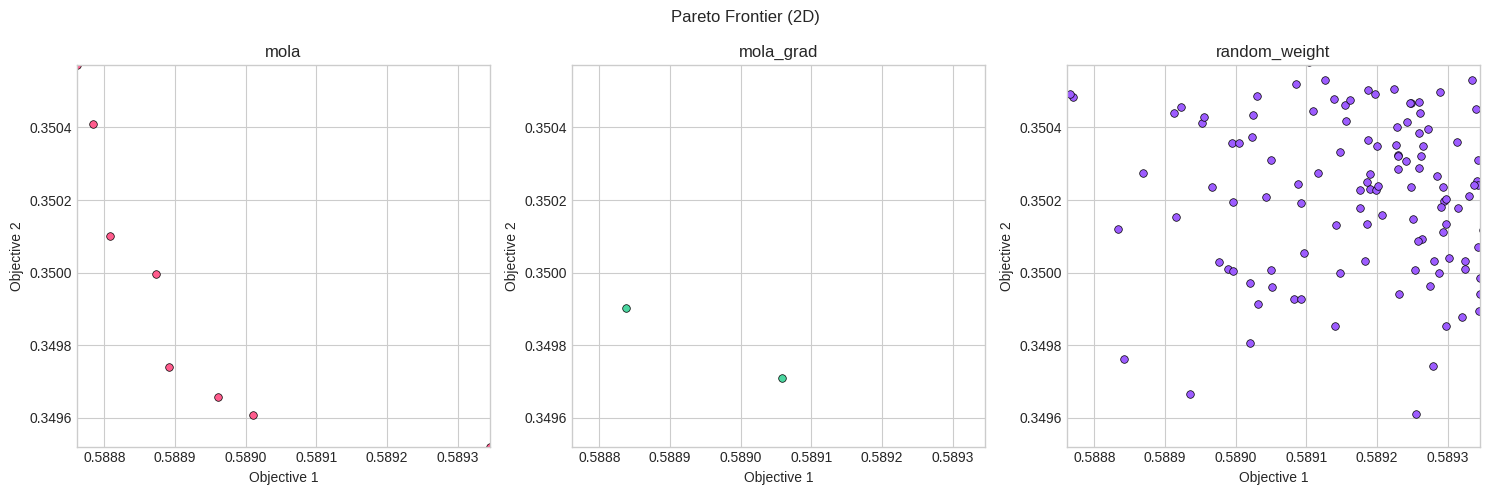

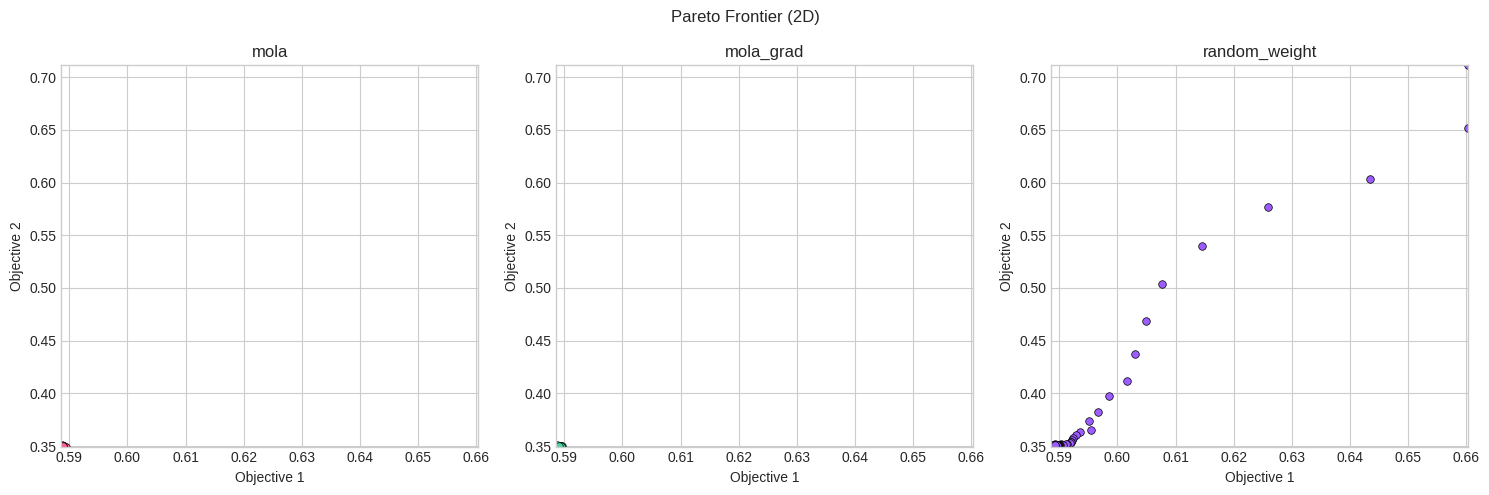

In [33]:
plot_pareto_2d_set_limit(pareto_dict, colors=colors_hv, axis_mode="first")
plot_pareto_2d_set_limit(pareto_dict, colors=colors_hv, axis_mode="global") 